In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
print("Libraries loaded")

Libraries loaded


In [ ]:
df = pd.read_csv("books_week1_final.csv")
print("Loaded:", df.shape)
print(df.head(3))

Loaded: (14021, 20)
                              title          authors  first_publish_year  \
0               Pride and Prejudice      Jane Austen              1813.0   
1  Alice's Adventures in Wonderland    Lewis Carroll              1865.0   
2                 A Christmas Carol  Charles Dickens              1843.0   

   edition_count  subject_count  has_cover  is_available_online    genre  \
0           4038             95          1                    1  fiction   
1           3546            176          1                    1  fiction   
2           3198            186          1                    1  fiction   

   avg_rating  ratings_count  page_count  review_length  price_usd  book_age  \
0    4.199488          391.0         343            467       8.49     212.0   
1    4.059091          220.0         313            331      10.80     160.0   
2    3.962617          107.0         351            336       9.92     182.0   

   has_rating  review_density  ratings_norm  edit

Drop leakage columns
Removes ratings_norm, editions_norm, popularity_score — these would leak the answer to the model
Drop text columns-Removes title, authors — not usable as ML features

In [ ]:
drop_cols = ["ratings_norm", "editions_norm", "popularity_score", "title", "authors"]
df.drop(columns=drop_cols, inplace=True)
print("Remaining columns:", df.columns.tolist())
print("Shape:", df.shape)

Remaining columns: ['first_publish_year', 'edition_count', 'subject_count', 'has_cover', 'is_available_online', 'genre', 'avg_rating', 'ratings_count', 'page_count', 'review_length', 'price_usd', 'book_age', 'has_rating', 'review_density', 'is_popular']
Shape: (14021, 15)


In [ ]:
# Create price_category now so it is available for analysis
price_bins   = [0, 12.99, 18.99, 999]
price_labels = ["Budget", "Mid-Range", "Premium"]
df["price_category"] = pd.cut(df["price_usd"], bins=price_bins, labels=price_labels)

print("price_category created")
print(df["price_category"].value_counts())

price_category created
price_category
Mid-Range    8173
Premium      3054
Budget       2794
Name: count, dtype: int64


In [ ]:
print("=== DATASET OVERVIEW ===")
print(f"Rows    : {len(df)}")
print(f"Columns : {len(df.columns)}")
print()
print(df.describe().round(2).to_string())

=== DATASET OVERVIEW ===
Rows    : 14021
Columns : 16

       first_publish_year  edition_count  subject_count  has_cover  is_available_online  avg_rating  ratings_count  page_count  review_length  price_usd  book_age  has_rating  review_density  is_popular
count            14021.00       14021.00       14021.00   14021.00              14021.0    14021.00       14021.00    14021.00       14021.00   14021.00  14021.00    14021.00        14021.00    14021.00
mean              1948.87          52.25          17.03       0.94                  0.8        3.98           7.48      282.84         205.53      16.27     72.06        0.44            0.77        0.30
std                 91.55         154.77          17.09       0.24                  0.4        0.50          35.44       66.32          55.12       4.06     73.68        0.50            0.29        0.46
min                  0.00           0.00           1.00       0.00                  0.0        1.00           0.00       88.00       

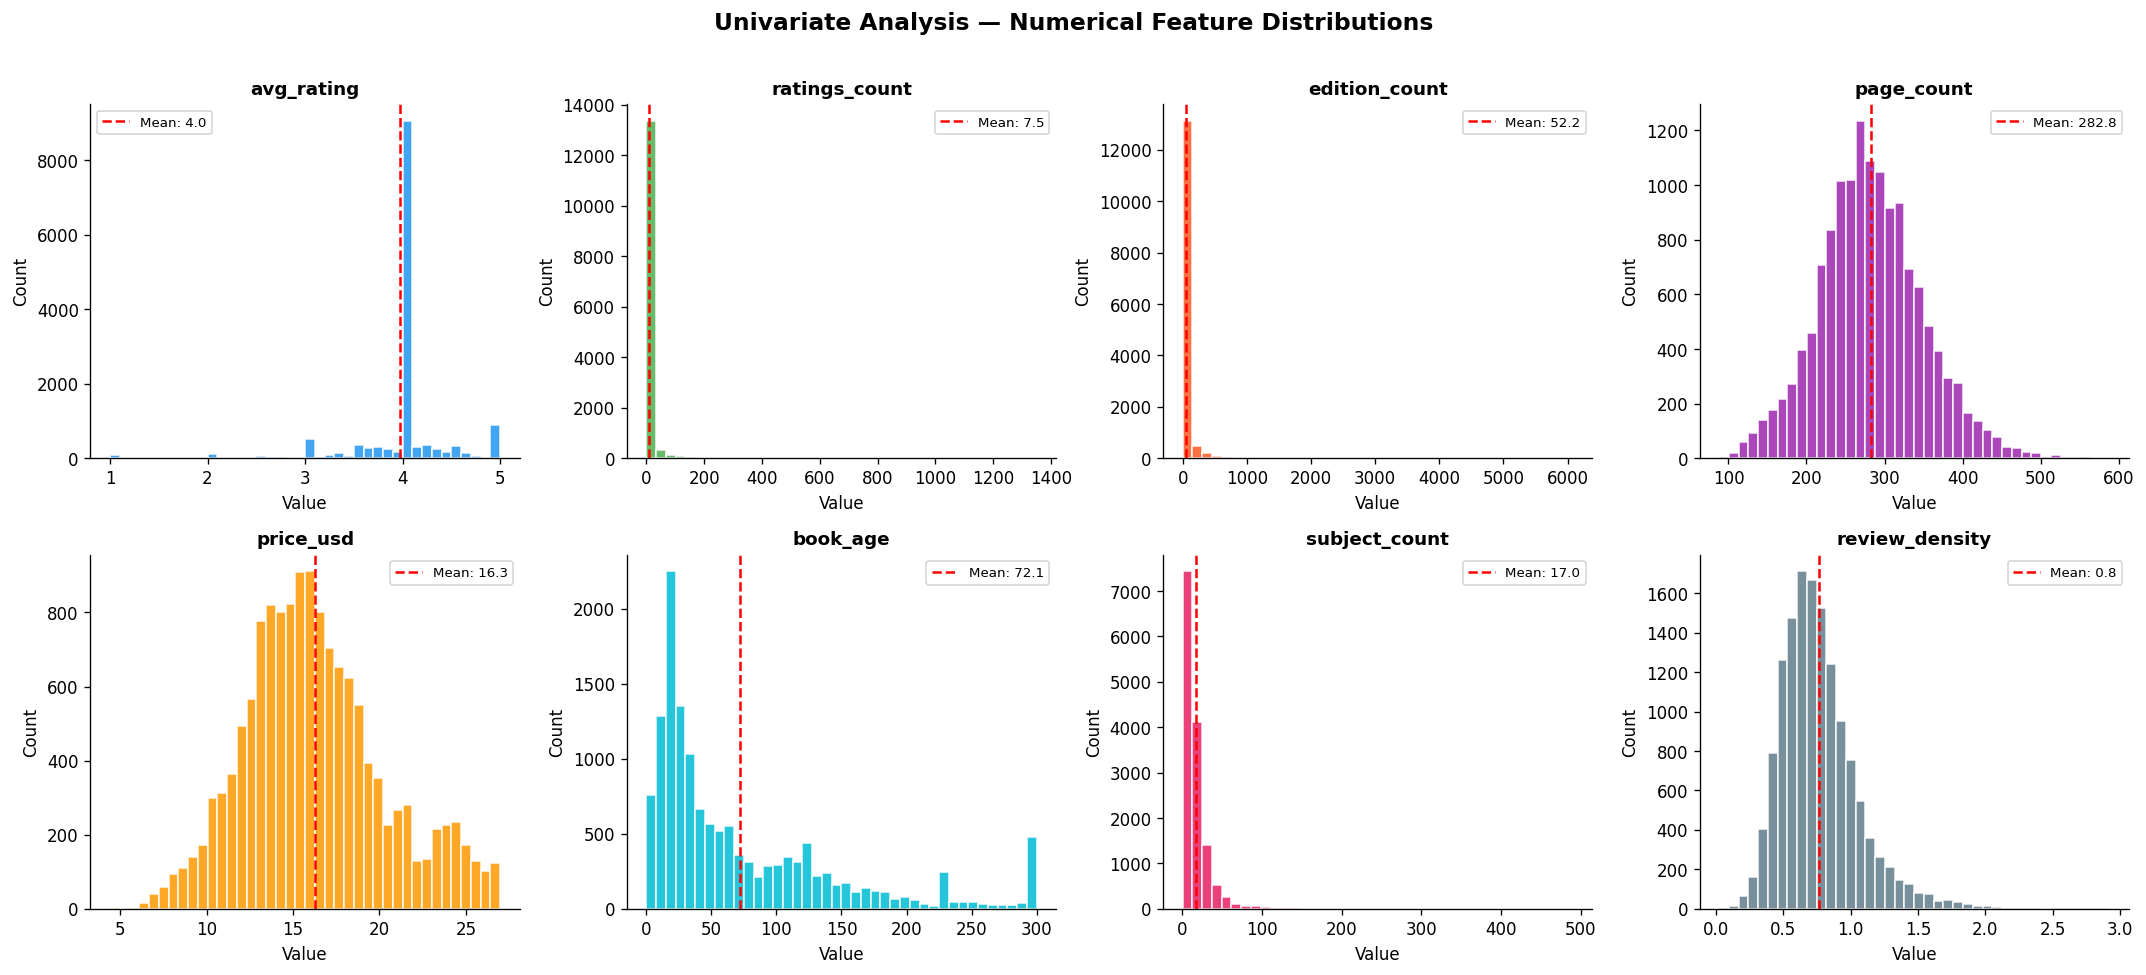

Observation: edition_count and ratings_count are heavily right-skewed — most books have low values but a few classics have extremely high values.


In [ ]:
num_features = ["avg_rating", "ratings_count", "edition_count",
                "page_count", "price_usd", "book_age",
                "subject_count", "review_density"]

colors = ["#2196F3","#4CAF50","#FF5722","#9C27B0",
          "#FF9800","#00BCD4","#E91E63","#607D8B"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=40, color=colors[i], edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color="red", linestyle="--", linewidth=1.5,
                    label=f"Mean: {mean_val:.1f}")
    axes[i].legend(fontsize=8)

plt.suptitle("Univariate Analysis — Numerical Feature Distributions",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("univariate_distributions.png", bbox_inches="tight")
plt.show()
print("Observation: edition_count and ratings_count are heavily right-skewed — most books have low values but a few classics have extremely high values.")

### Observations — Histograms

| Feature | Shape | Mean | Key Observation |
|---|---|---|---|
| avg_rating | Left-skewed | 3.978 | Most books rated 3.5–4.5. Very few below 2.0. Rating distribution is compressed — not very discriminative on its own |
| ratings_count | Extreme right-skew | 7.48 | Over 55% of books have 0 ratings. A tiny fraction of famous books (classics) dominate with 100–1350 ratings. Median is 0 |
| edition_count | Extreme right-skew | 52.25 | Median is 17 but mean is 52 — pulled up by classics like Pride and Prejudice (4038 editions). Max is 6084 |
| page_count | Approximately normal | 282.8 | Follows a near-normal bell curve centered at ~280 pages. Most books are 200–400 pages. This is the least skewed feature |
| price_usd | Slight right-skew | 16.27 | Prices cluster between $12–$20 (mid-range). A few premium books push the tail to $27 |
| book_age | Right-skewed | 72.06 | Most books are modern (0–100 years). A long tail of historical classics extends to 300 years old |
| subject_count | Extreme right-skew | 17.03 | Majority of books have 5–25 subject tags. A few reference/encyclopedic works have 100–490 tags |
| review_density | Right-skewed | 0.767 | Most books have review density 0.5–1.0. A small number of short but heavily reviewed books push the tail |

**Summary:** `ratings_count`, `edition_count`, and `subject_count` are severely right-skewed with extreme outliers. These require outlier treatment before ML modeling.

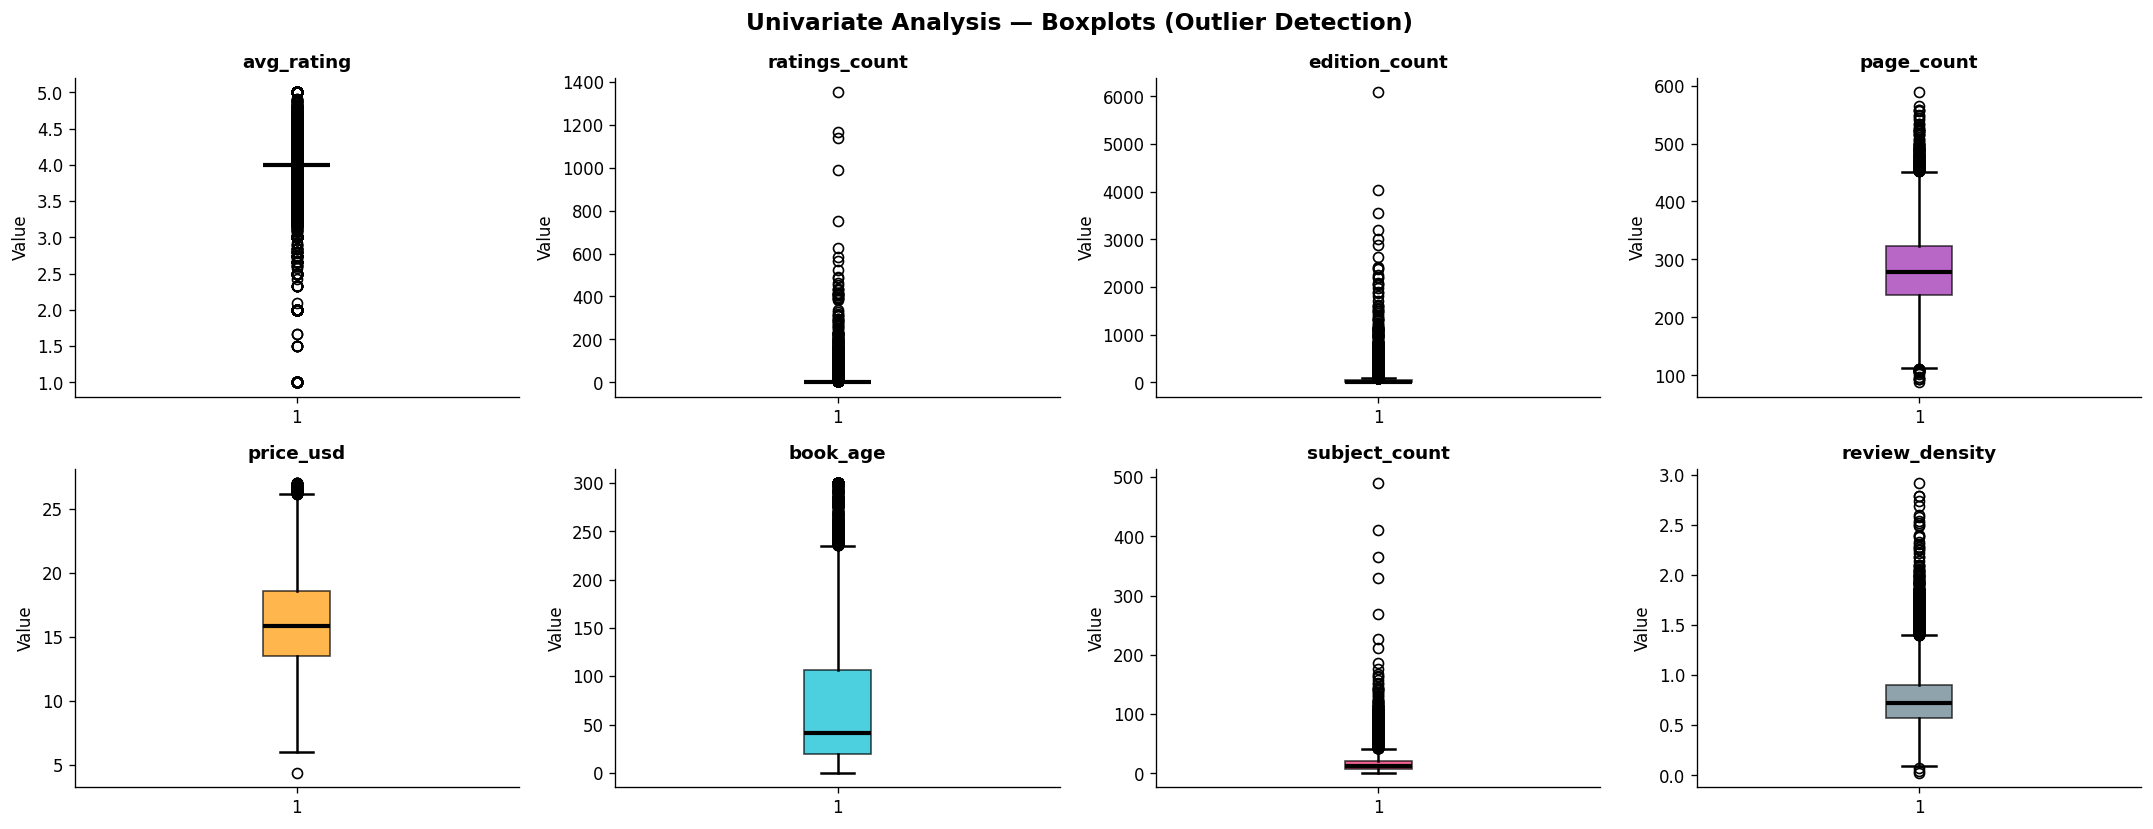

Observation: edition_count, ratings_count, and subject_count show significant outliers above the whiskers — these will be capped in preprocessing.


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor=colors[i], alpha=0.7),
                    medianprops=dict(color="black", linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Value")

plt.suptitle("Univariate Analysis — Boxplots (Outlier Detection)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("univariate_boxplots.png", bbox_inches="tight")
plt.show()
print("Observation: edition_count, ratings_count, and subject_count show significant outliers above the whiskers — these will be capped in preprocessing.")

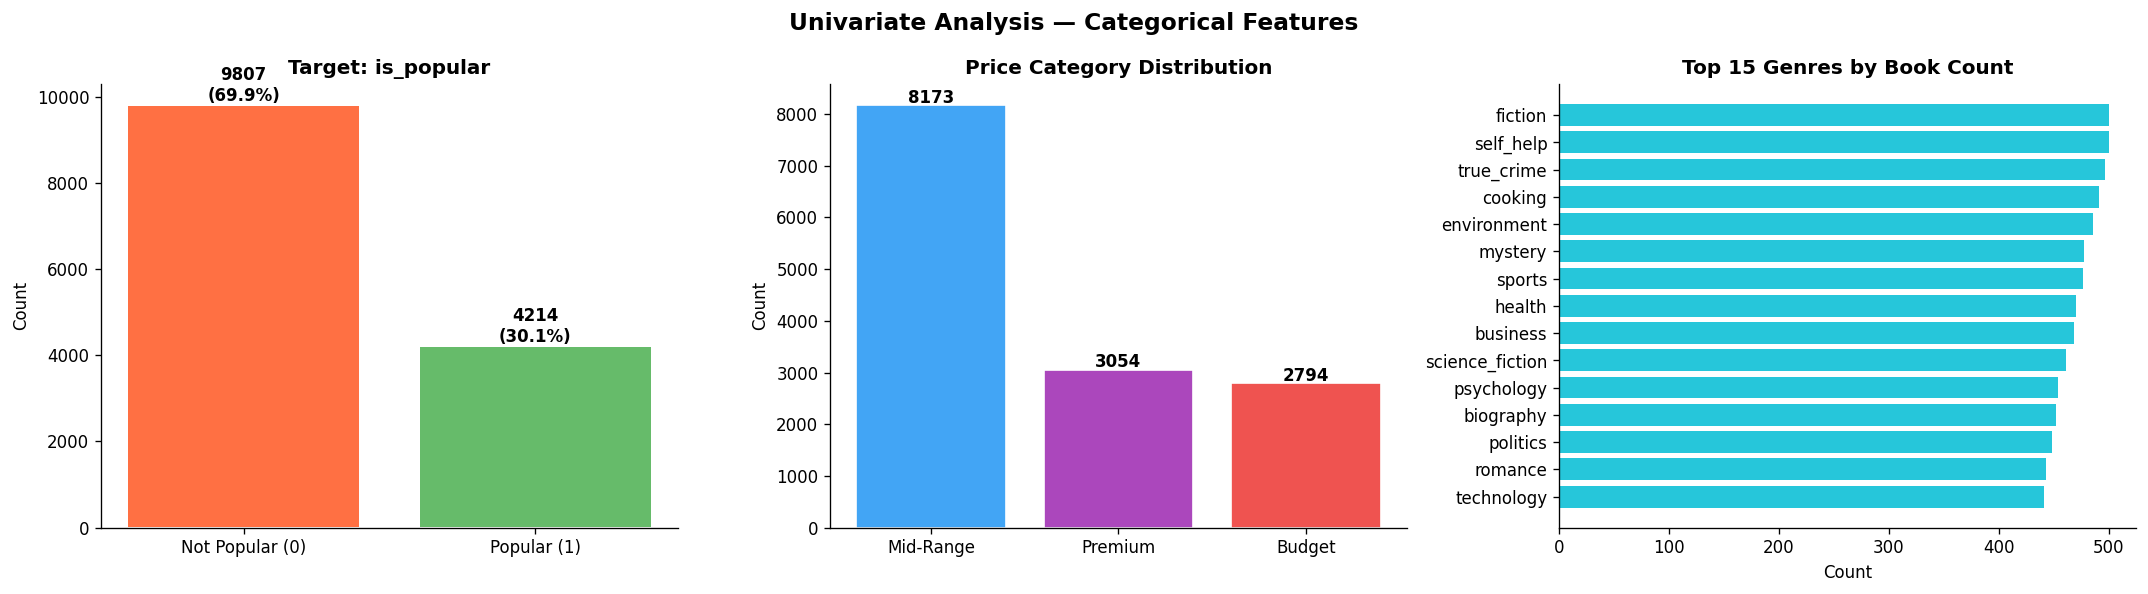

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Target variable
counts = df["is_popular"].value_counts()
axes[0].bar(["Not Popular (0)", "Popular (1)"], counts.values,
            color=["#FF7043", "#66BB6A"], edgecolor="white", linewidth=1.2)
axes[0].set_title("Target: is_popular", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v+100, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontweight="bold")

# Price category
pcat = df["price_category"].value_counts()
axes[1].bar(pcat.index, pcat.values,
            color=["#42A5F5","#AB47BC","#EF5350"], edgecolor="white")
axes[1].set_title("Price Category Distribution", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Count")
for i, v in enumerate(pcat.values):
    axes[1].text(i, v+50, str(v), ha="center", fontweight="bold")

# Genre counts
top_genres = df["genre"].value_counts().head(15)
axes[2].barh(top_genres.index[::-1], top_genres.values[::-1], color="#26C6DA")
axes[2].set_title("Top 15 Genres by Book Count", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Count")

plt.suptitle("Univariate Analysis — Categorical Features",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("univariate_categorical.png", bbox_inches="tight")
plt.show()

### Observations — Categorical Features

**Target Variable (is_popular):**
- 9,807 books (70.0%) are **Not Popular**
- 4,214 books (30.0%) are **Popular**
- This is a **moderate class imbalance** — not severe enough to require oversampling (SMOTE) but the ML model must use `class_weight='balanced'` or evaluate using F1-score and AUC rather than raw accuracy

**Price Category:**
- Mid-Range ($13–$19) dominates with 8,173 books (58.3%) — most books are priced in this band
- Premium (>$19): 3,054 books (21.8%)
- Budget (<$13): 2,794 books (19.9%)
- Distribution is uneven — Mid-Range has nearly 3× more books than Budget or Premium

**Genre Distribution:**
- `fiction` and `self_help` are the most collected genres (~500 each)
- `classic_literature` and `dystopia` have the fewest books (80 and 90) — Open Library has fewer books tagged under these specific terms
- Genre imbalance is present but acceptable since most genres have 300–500 books

In [ ]:
summary = df[num_features].describe().T
summary["skewness"] = df[num_features].skew().round(3)
summary["kurtosis"] = df[num_features].kurt().round(3)
print("=== UNIVARIATE SUMMARY STATISTICS ===")
print()
print(summary.round(3).to_string())
print()
print("High skewness (>1): features that need outlier treatment before modeling")
print(df[num_features].skew()[df[num_features].skew() > 1].index.tolist())

=== UNIVARIATE SUMMARY STATISTICS ===

                  count     mean      std     min      25%      50%      75%       max  skewness  kurtosis
avg_rating      14021.0    3.978    0.495   1.000    4.000    4.000    4.000     5.000    -1.757     9.309
ratings_count   14021.0    7.484   35.440   0.000    0.000    0.000    3.000  1350.000    16.021   411.644
edition_count   14021.0   52.248  154.772   0.000    8.000   17.000   39.000  6084.000    12.934   294.965
page_count      14021.0  282.837   66.319  88.000  239.000  279.000  324.000   588.000     0.254     0.324
price_usd       14021.0   16.265    4.062   4.400   13.480   15.830   18.550    26.990     0.441    -0.060
book_age        14021.0   72.061   73.675   0.000   20.000   41.000  106.000   300.000     1.556     1.824
subject_count   14021.0   17.033   17.089   1.000    7.000   13.000   21.000   490.000     6.103    97.317
review_density  14021.0    0.767    0.286   0.025    0.574    0.723    0.905     2.919     1.281     3.45

Bivariate Analysis

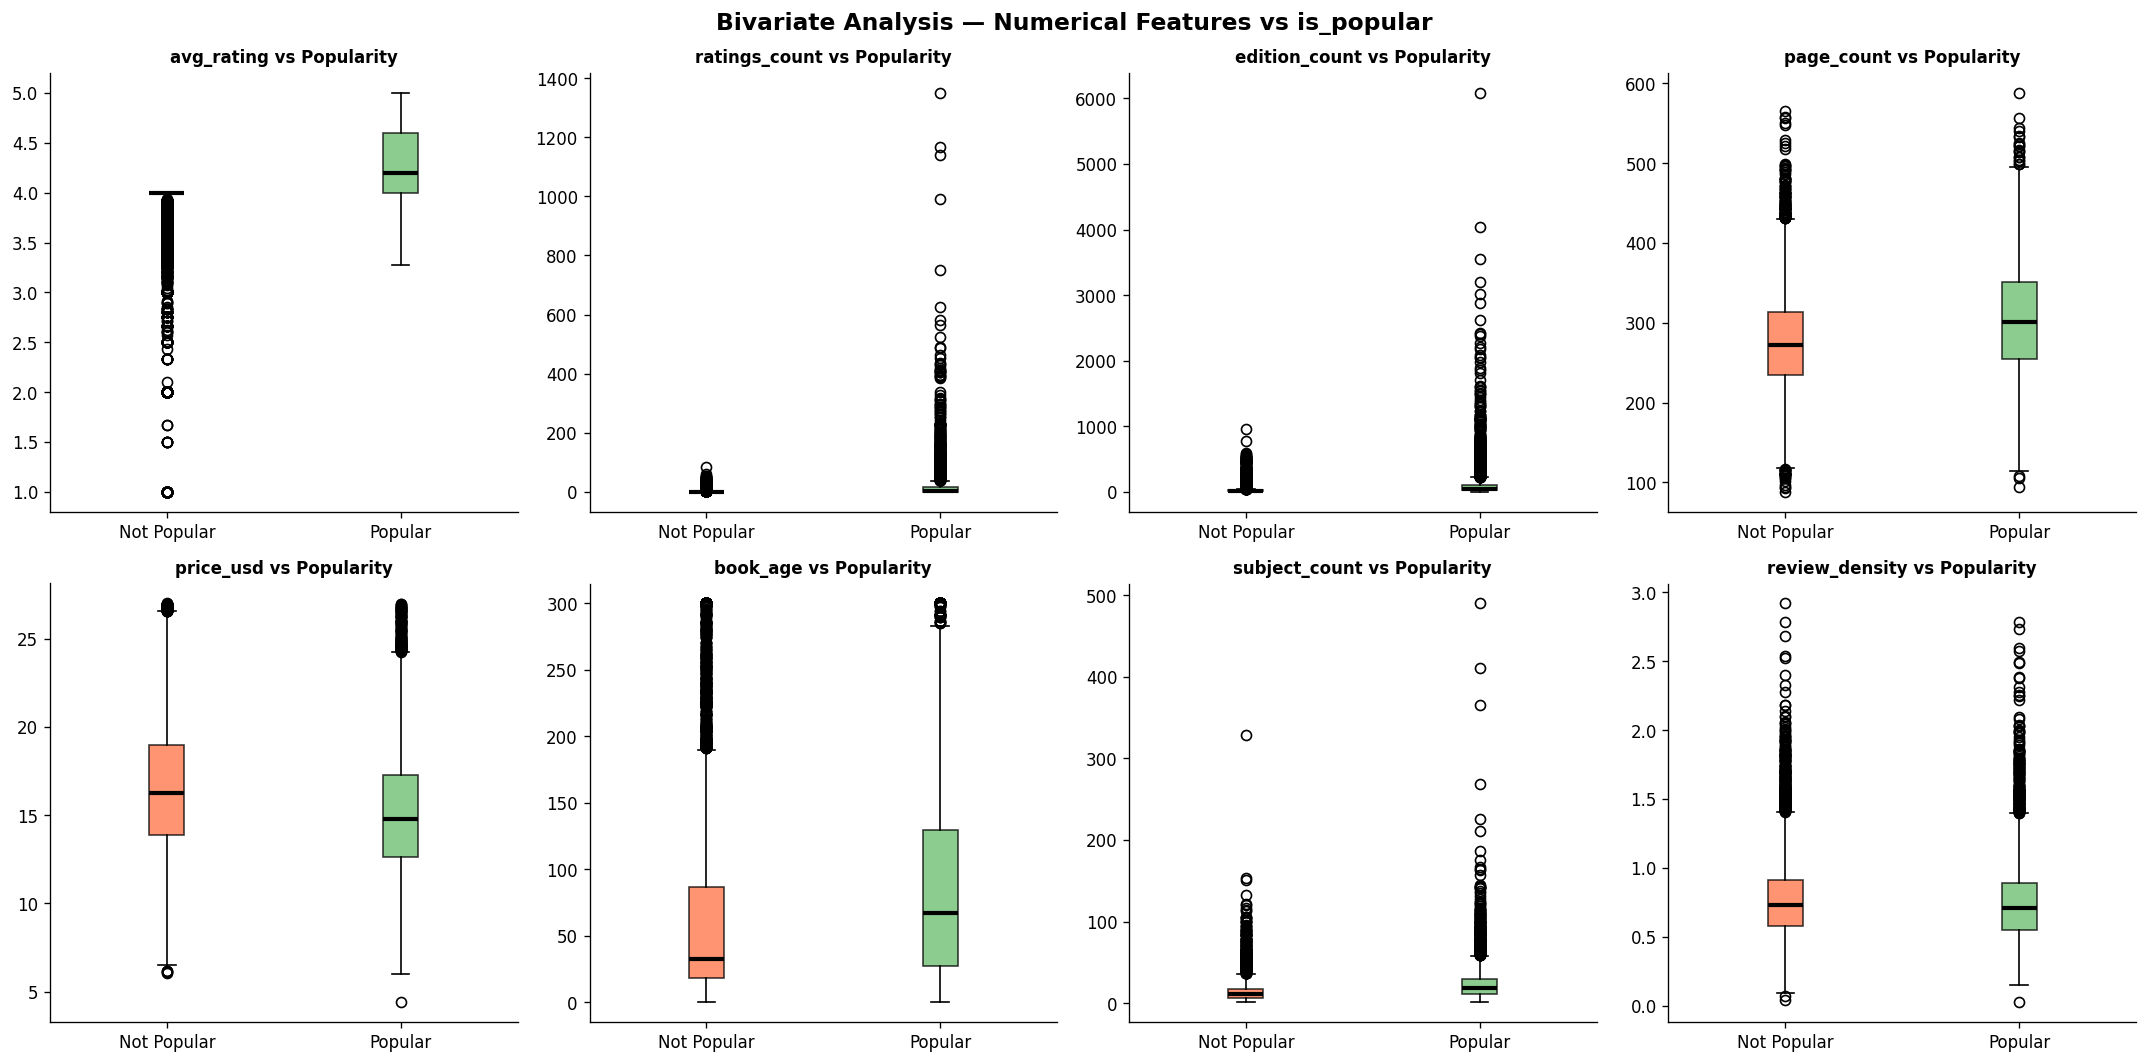

Observation: Popular books have clearly higher edition_count and ratings_count medians. avg_rating shows minimal difference — quantity of engagement matters more than score.


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(num_features):
    data_0 = df[df["is_popular"] == 0][col]
    data_1 = df[df["is_popular"] == 1][col]
    bp = axes[i].boxplot([data_0, data_1],
                          patch_artist=True,
                          labels=["Not Popular", "Popular"],
                          medianprops=dict(color="black", linewidth=2.5))
    bp["boxes"][0].set_facecolor("#FF7043")
    bp["boxes"][0].set_alpha(0.75)
    bp["boxes"][1].set_facecolor("#66BB6A")
    bp["boxes"][1].set_alpha(0.75)
    axes[i].set_title(f"{col} vs Popularity", fontsize=10, fontweight="bold")

plt.suptitle("Bivariate Analysis — Numerical Features vs is_popular",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("bivariate_vs_target.png", bbox_inches="tight")
plt.show()
print("Observation: Popular books have clearly higher edition_count and ratings_count medians. avg_rating shows minimal difference — quantity of engagement matters more than score.")

### Observations — Numerical Features vs Target

| Feature | Not Popular Mean | Popular Mean | Difference | Predictive Power |
|---|---|---|---|---|
| avg_rating | 3.825 | 4.333 | +0.508 | **Strong** — popular books are clearly rated higher |
| ratings_count | 1.418 | 21.599 | +20.18 | **Strong** — popular books have 15× more ratings |
| edition_count | 23.371 | 119.453 | +96.08 | **Strong** — popular books have 5× more editions |
| page_count | 274.5 | 302.3 | +27.8 | **Moderate** — popular books tend to be slightly longer |
| price_usd | 16.770 | 15.092 | -1.678 | **Moderate** — popular books are slightly cheaper |
| book_age | 63.365 | 92.299 | +28.93 | **Moderate** — popular books tend to be older (classics) |
| subject_count | 13.779 | 24.607 | +10.83 | **Strong** — popular books have more topic tags |
| review_density | 0.769 | 0.760 | -0.009 | **Weak** — almost no difference between classes |

**Most discriminating features:**
1. `avg_rating` — the median box for popular books sits noticeably higher
2. `edition_count` — popular books have a dramatically higher median and wider spread
3. `ratings_count` — same pattern as edition_count
4. `subject_count` — popular books are tagged under more topics

**Least discriminating:**
- `review_density` — nearly identical distributions for both classes, making it a weak predictor

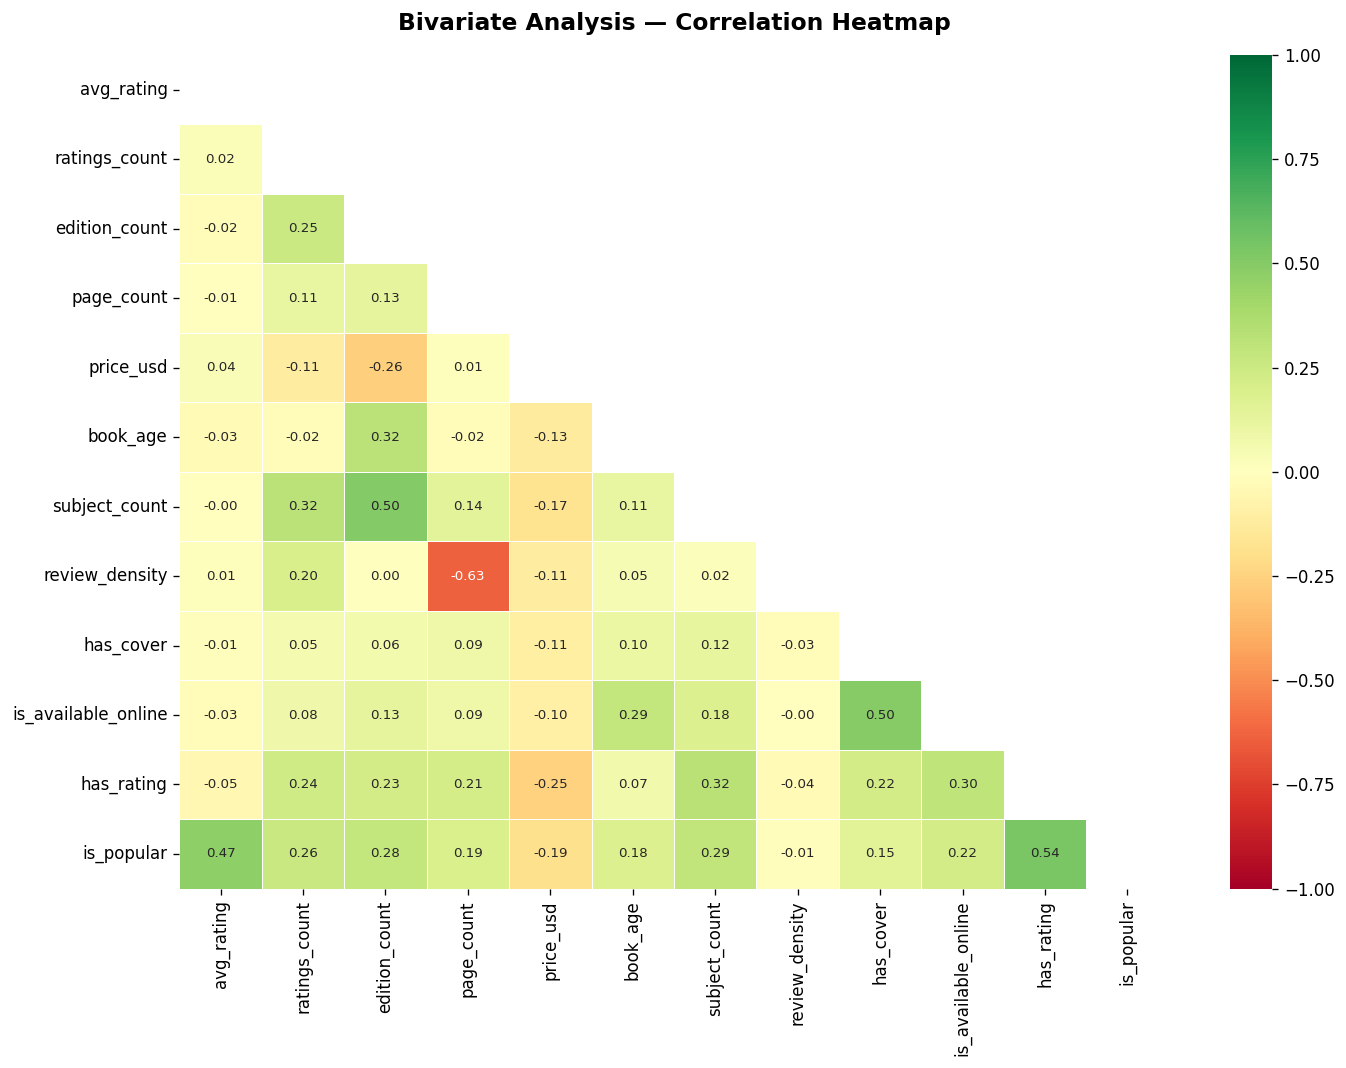

In [ ]:
corr_cols = num_features + ["has_cover","is_available_online","has_rating","is_popular"]
corr = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            mask=mask, linewidths=0.5,
            annot_kws={"size": 8}, vmin=-1, vmax=1)
plt.title("Bivariate Analysis — Correlation Heatmap",
          fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("bivariate_correlation.png", bbox_inches="tight")
plt.show()

### Observations — Correlation Heatmap

**Strong correlations with is_popular (|r| > 0.25):**
| Feature Pair | Correlation | Meaning |
|---|---|---|
| has_rating → is_popular | +0.54 | Books with real ratings are much more likely to be popular — rating presence itself signals popularity |
| avg_rating → is_popular | +0.47 | Higher rated books are more popular |
| subject_count → is_popular | +0.29 | More topic tags = more popular |
| edition_count → is_popular | +0.28 | More editions = more popular |
| ratings_count → is_popular | +0.26 | More raters = more popular |
| price_usd → is_popular | -0.19 | Cheaper books tend to be more popular (classics and reprints are cheaper) |

**Notable inter-feature correlations:**
| Feature Pair | Correlation | Concern |
|---|---|---|
| page_count ↔ review_density | -0.635 | **High multicollinearity** — longer books have lower review density by definition (mathematical relationship). One of these may be dropped before linear modeling |
| edition_count ↔ subject_count | +0.505 | Moderately correlated — classic books accumulate both editions and tags over time |
| has_cover ↔ is_available_online | +0.496 | Books available online also tend to have cover images |
| subject_count ↔ ratings_count | +0.315 | More tagged books get more attention |

**Weak correlations (|r| < 0.05):**
- `review_density` with `is_popular` (r = -0.015) — nearly zero, confirms it is a weak predictor
- `avg_rating` with `edition_count` (r = -0.019) — high ratings don't directly cause more editions

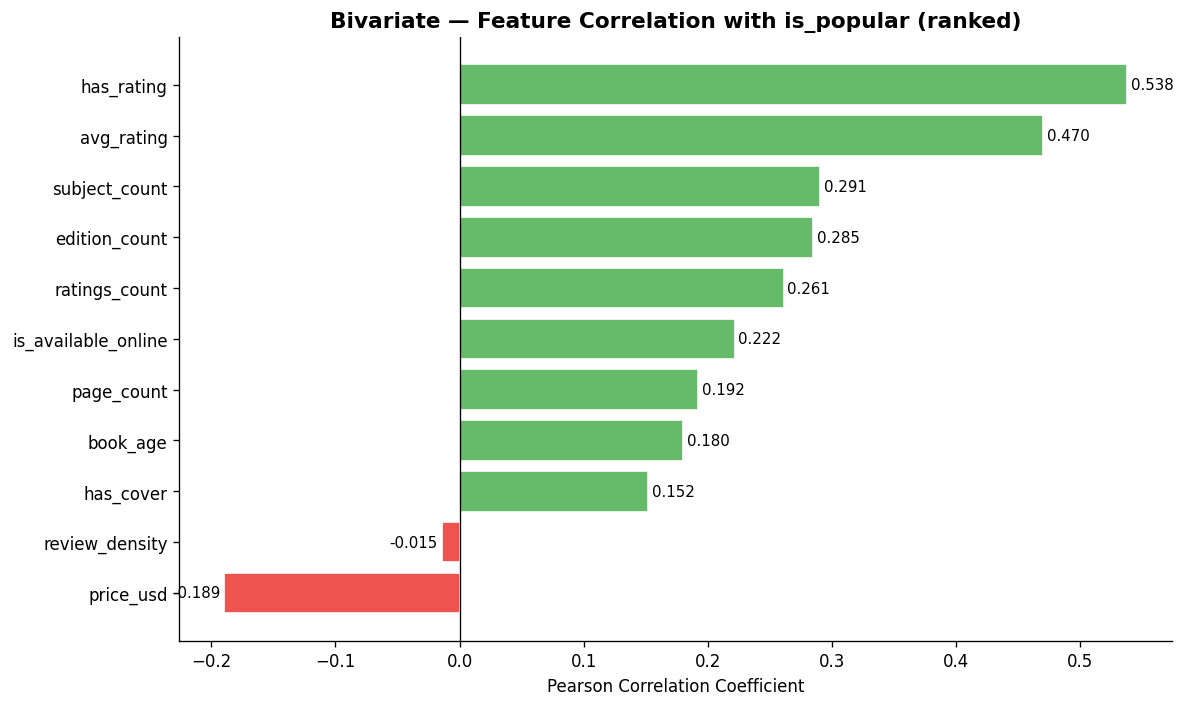

Top predictors of popularity:
ratings_count    0.261
edition_count    0.285
subject_count    0.291
avg_rating       0.470
has_rating       0.538
Name: is_popular, dtype: float64


In [ ]:
target_corr = df[corr_cols].corr()["is_popular"].drop("is_popular").sort_values()
bar_colors  = ["#EF5350" if v < 0 else "#66BB6A" for v in target_corr.values]

plt.figure(figsize=(10, 6))
plt.barh(target_corr.index, target_corr.values, color=bar_colors, edgecolor="white")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Bivariate — Feature Correlation with is_popular (ranked)",
          fontsize=13, fontweight="bold")
plt.xlabel("Pearson Correlation Coefficient")
for i, v in enumerate(target_corr.values):
    ha     = "left" if v >= 0 else "right"
    offset = 0.003 if v >= 0 else -0.003
    plt.text(v + offset, i, f"{v:.3f}", va="center", ha=ha, fontsize=9)
plt.tight_layout()
plt.savefig("bivariate_target_correlation.png", bbox_inches="tight")
plt.show()
print("Top predictors of popularity:")
print(target_corr.tail(5).round(3))

### Observations — Feature Ranking

**Positive predictors (green — higher value = more likely popular):**
1. `has_rating` (0.538) — strongest single predictor. Whether a book has ratings at all is more predictive than the rating value
2. `avg_rating` (0.470) — second strongest. Popular books are genuinely better rated
3. `subject_count` (0.291) — popular books are catalogued under more topics
4. `edition_count` (0.285) — popular books have been reprinted more
5. `ratings_count` (0.261) — popular books have more raters
6. `is_available_online` (0.222) — popular/classic books are more accessible online
7. `page_count` (0.192) — popular books tend to be slightly longer
8. `book_age` (0.180) — older books (classics) tend to be more popular
9. `has_cover` (0.152) — popular books more likely to have cover images

**Negative predictors (red — higher value = less likely popular):**
1. `price_usd` (-0.189) — popular books are cheaper on average (classic reprints are inexpensive)
2. `review_density` (-0.015) — essentially zero correlation, near-useless predictor

**Implication for modeling:** `has_rating`, `avg_rating`, and `subject_count` are the top 3 features to prioritize. `review_density` may be dropped to reduce noise.

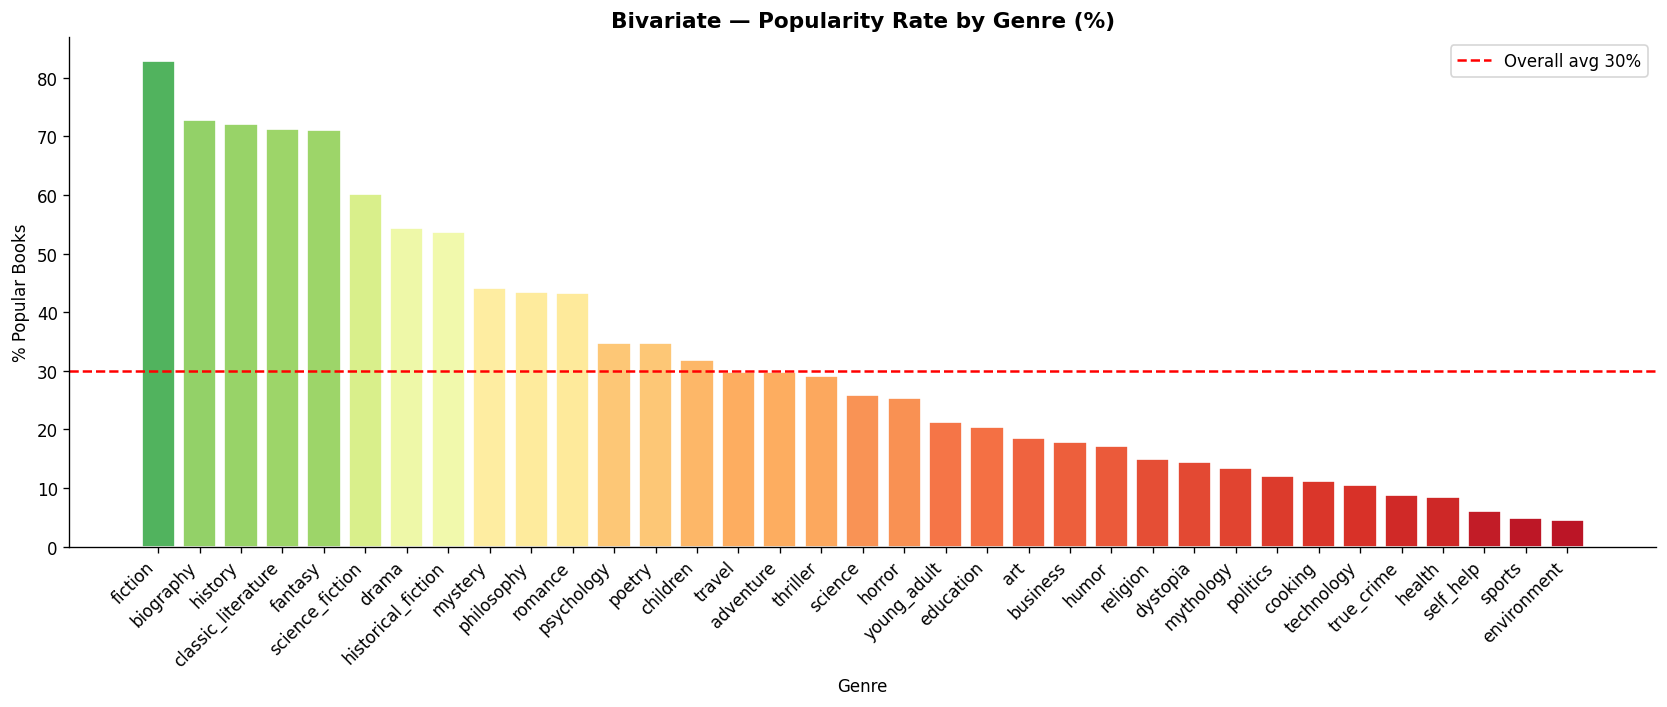

Genres above average popularity rate:
genre
fiction               82.8
biography             72.8
history               72.1
classic_literature    71.2
fantasy               71.1
science_fiction       60.1
drama                 54.4
historical_fiction    53.7
mystery               44.1
philosophy            43.5
romance               43.3
psychology            34.8
poetry                34.8
children              31.9
Name: is_popular, dtype: float64


In [ ]:
genre_pop = df.groupby("genre")["is_popular"].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
bar_c = plt.cm.RdYlGn(genre_pop.values)
plt.bar(genre_pop.index, genre_pop.values * 100, color=bar_c, edgecolor="white")
plt.axhline(30, color="red", linestyle="--", linewidth=1.5, label="Overall avg 30%")
plt.title("Bivariate — Popularity Rate by Genre (%)", fontsize=13, fontweight="bold")
plt.xlabel("Genre")
plt.ylabel("% Popular Books")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("bivariate_genre.png", bbox_inches="tight")
plt.show()
print("Genres above average popularity rate:")
print((genre_pop[genre_pop > 0.30] * 100).round(1))

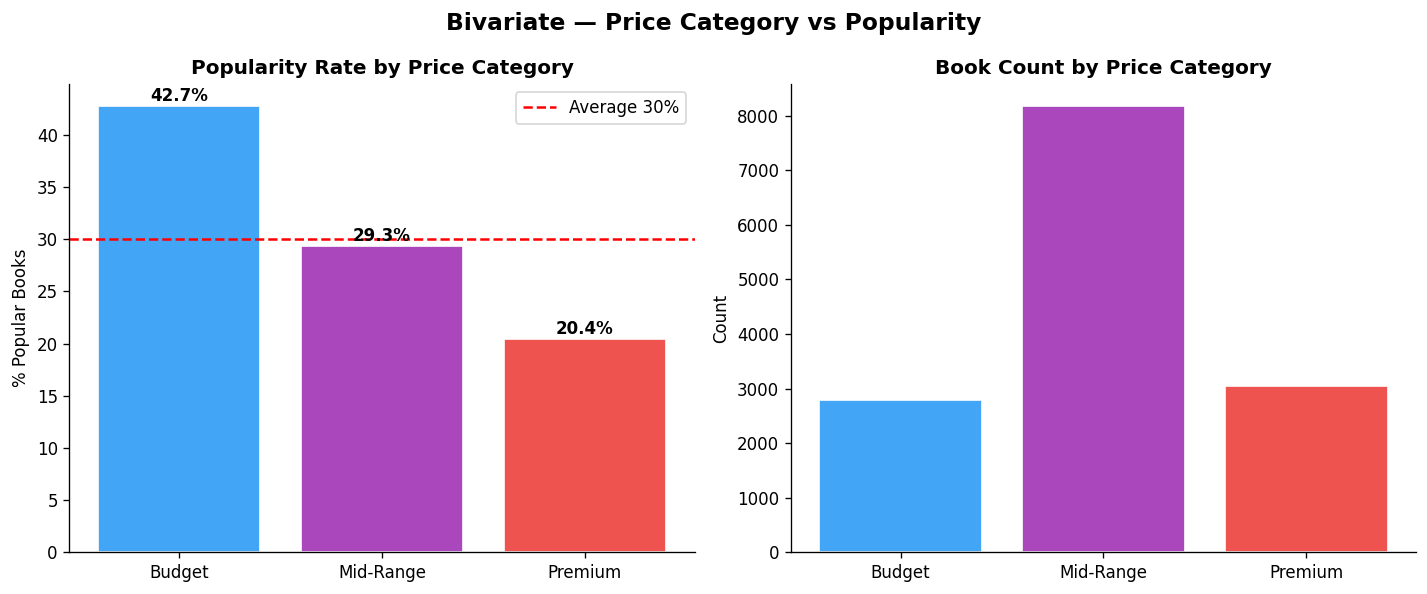

In [ ]:
pcat_pop   = df.groupby("price_category")["is_popular"].mean() * 100
pcat_count = df.groupby("price_category")["is_popular"].count()
cat_colors = ["#42A5F5","#AB47BC","#EF5350"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(pcat_pop.index, pcat_pop.values, color=cat_colors, edgecolor="white")
axes[0].axhline(30, color="red", linestyle="--", label="Average 30%")
axes[0].set_title("Popularity Rate by Price Category", fontsize=12, fontweight="bold")
axes[0].set_ylabel("% Popular Books")
axes[0].legend()
for i, v in enumerate(pcat_pop.values):
    axes[0].text(i, v+0.5, f"{v:.1f}%", ha="center", fontweight="bold")

axes[1].bar(pcat_count.index, pcat_count.values, color=cat_colors, edgecolor="white")
axes[1].set_title("Book Count by Price Category", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Count")

plt.suptitle("Bivariate — Price Category vs Popularity",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("bivariate_price.png", bbox_inches="tight")
plt.show()

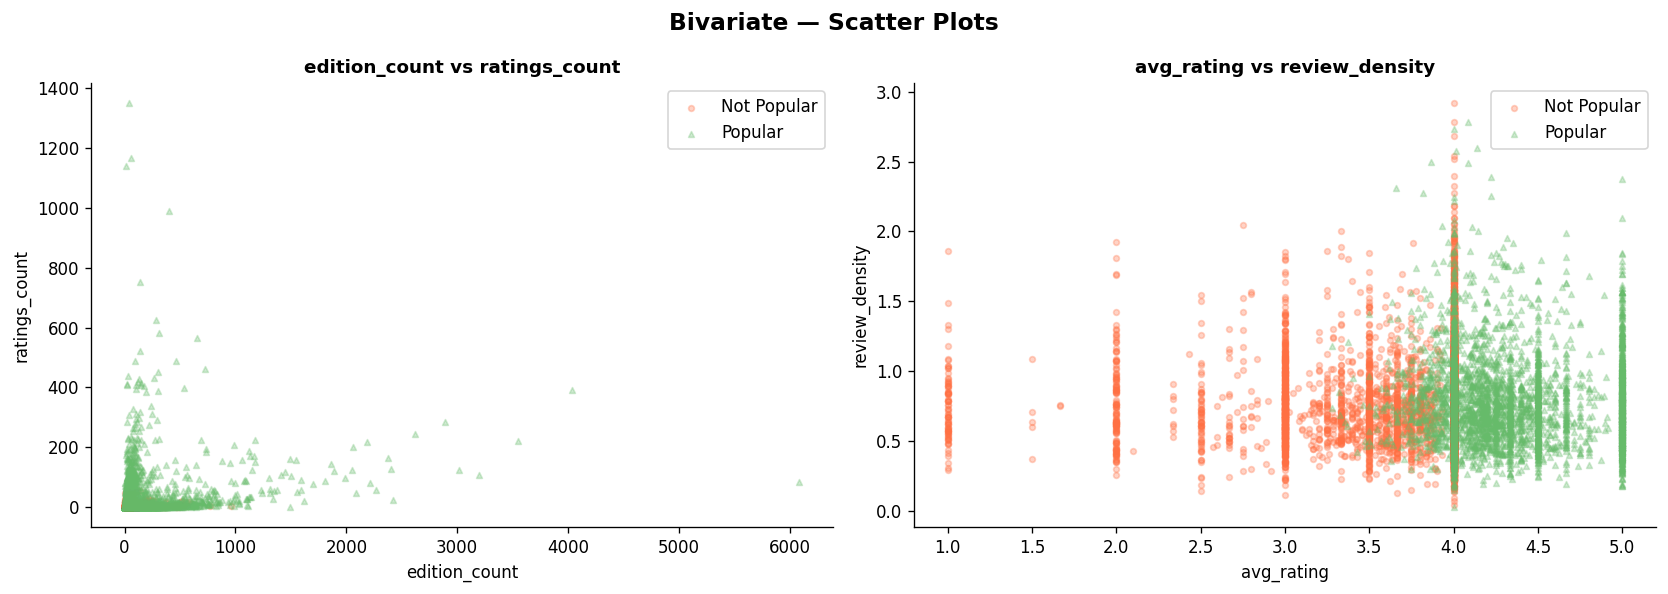

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pairs = [("edition_count","ratings_count"), ("avg_rating","review_density")]

for ax, (xcol, ycol) in zip(axes, pairs):
    for label, color, marker in zip([0,1],["#FF7043","#66BB6A"],["o","^"]):
        sub = df[df["is_popular"]==label]
        ax.scatter(sub[xcol], sub[ycol], c=color, alpha=0.3, s=12,
                   label="Popular" if label else "Not Popular", marker=marker)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(f"{xcol} vs {ycol}", fontsize=11, fontweight="bold")
    ax.legend()

plt.suptitle("Bivariate — Scatter Plots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("bivariate_scatter.png", bbox_inches="tight")
plt.show()

Preprocessing

In [ ]:
# Cap outliers at 1st and 99th percentile
# Reason: boxplots showed extreme values in these columns
def cap_outliers(series, lower_q=0.01, upper_q=0.99):
    lo = series.quantile(lower_q)
    hi = series.quantile(upper_q)
    return series.clip(lo, hi)

print("Before capping:")
print(df[["edition_count","ratings_count","subject_count"]].describe().loc[["max"]].round(1))

df["edition_count"]  = cap_outliers(df["edition_count"])
df["ratings_count"]  = cap_outliers(df["ratings_count"])
df["subject_count"]  = cap_outliers(df["subject_count"])
df["review_length"]  = cap_outliers(df["review_length"])
df["review_density"] = cap_outliers(df["review_density"])

print("After capping:")
print(df[["edition_count","ratings_count","subject_count"]].describe().loc[["max"]].round(1))

Before capping:
     edition_count  ratings_count  subject_count
max         6084.0         1350.0          490.0
After capping:
     edition_count  ratings_count  subject_count
max          633.8          129.0           84.0


In [ ]:
# Recalculate review_density cleanly after capping review_length
df["review_density"] = (df["review_length"] / (df["page_count"] + 1)).round(4)
print("review_density recalculated")
print(df["review_density"].describe().round(4))

review_density recalculated
count    14021.0000
mean         0.7648
std          0.2790
min          0.1845
25%          0.5738
50%          0.7231
75%          0.9043
max          2.9189
Name: review_density, dtype: float64


In [ ]:
# price_category already created — just encode it to numbers for ML
price_map = {"Budget": 0, "Mid-Range": 1, "Premium": 2}
df["price_cat_encoded"] = df["price_category"].map(price_map)
print("Price category encoded:")
print(df[["price_category","price_cat_encoded"]].value_counts().reset_index())

Price category encoded:
  price_category price_cat_encoded  count
0      Mid-Range                 1   8173
1        Premium                 2   3054
2         Budget                 0   2794


In [ ]:
# Label Encoding — for tree-based models (Random Forest, XGBoost)
le = LabelEncoder()
df["genre_encoded"] = le.fit_transform(df["genre"])
print("Genre Label Encoding done")
print(df[["genre","genre_encoded"]].drop_duplicates().sort_values("genre").to_string())
print()
print("Total unique genres encoded:", df["genre_encoded"].nunique())

Genre Label Encoding done
                    genre  genre_encoded
3434            adventure              0
11042                 art              1
3821            biography              2
8021             business              3
6753             children              4
12730  classic_literature              5
7148              cooking              6
13727               drama              7
12810            dystopia              8
11435           education              9
12244         environment             10
1882              fantasy             11
0                 fiction             12
8490               health             13
2228   historical_fiction             14
5641              history             15
3001               horror             16
13319               humor             17
500               mystery             18
12900           mythology             19
5227           philosophy             20
9811               poetry             21
10593            politics      

In [ ]:
# One-Hot Encoding — for linear models (Logistic Regression)
# Saved as separate dataframe df_ohe
genre_dummies = pd.get_dummies(df["genre"], prefix="genre")
df_ohe = pd.concat([df, genre_dummies], axis=1)
print(f"One-Hot Encoding adds {len(genre_dummies.columns)} columns")
print("df_ohe shape:", df_ohe.shape)

One-Hot Encoding adds 35 columns
df_ohe shape: (14021, 53)


In [ ]:
# MinMaxScaler — scales all numerical features to 0-1 range
# Applied AFTER analysis so charts above showed real values
num_cols = ["edition_count", "subject_count", "avg_rating",
            "ratings_count", "page_count", "review_length",
            "price_usd", "book_age", "review_density"]

scaler   = MinMaxScaler()
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

print("MinMaxScaler applied — all numeric features now 0 to 1")
print(df_scaled[num_cols].describe().round(3))

MinMaxScaler applied — all numeric features now 0 to 1
       edition_count  subject_count  avg_rating  ratings_count  page_count  \
count      14021.000      14021.000   14021.000      14021.000   14021.000   
mean           0.072          0.189       0.744          0.047       0.390   
std            0.149          0.173       0.124          0.145       0.133   
min            0.000          0.000       0.000          0.000       0.000   
25%            0.011          0.072       0.750          0.000       0.302   
50%            0.025          0.145       0.750          0.000       0.382   
75%            0.060          0.241       0.750          0.023       0.472   
max            1.000          1.000       1.000          1.000       1.000   

       review_length  price_usd   book_age  review_density  
count      14021.000  14021.000  14021.000       14021.000  
mean           0.465      0.525      0.240           0.212  
std            0.202      0.180      0.246           0.102 

In [ ]:
print("=== FINAL PROCESSED DATASET ===")
print(f"Rows    : {len(df_scaled)}")
print(f"Columns : {len(df_scaled.columns)}")
print()
print("Null values:", df_scaled.isnull().sum().sum())
print()
print("All columns:")
for col in df_scaled.columns:
    print(f"  {col:30s} {str(df_scaled[col].dtype):10s}")
print()
print("is_popular distribution:")
print(df_scaled["is_popular"].value_counts())

=== FINAL PROCESSED DATASET ===
Rows    : 14021
Columns : 18

Null values: 0

All columns:
  first_publish_year             float64   
  edition_count                  float64   
  subject_count                  float64   
  has_cover                      int64     
  is_available_online            int64     
  genre                          object    
  avg_rating                     float64   
  ratings_count                  float64   
  page_count                     float64   
  review_length                  float64   
  price_usd                      float64   
  book_age                       float64   
  has_rating                     int64     
  review_density                 float64   
  is_popular                     int64     
  price_category                 category  
  price_cat_encoded              category  
  genre_encoded                  int64     

is_popular distribution:
is_popular
0    9807
1    4214
Name: count, dtype: int64


In [ ]:
df_scaled.to_csv("books_week2_processed.csv", index=False)
print("Saved: books_week2_processed.csv")
print("Shape:", df_scaled.shape)

# Also save the one-hot encoded version
df_ohe_scaled = df_ohe.copy()
df_ohe_scaled[num_cols] = scaler.transform(df_ohe[num_cols])
df_ohe_scaled.to_csv("books_week2_ohe.csv", index=False)
print("Saved: books_week2_ohe.csv (with one-hot encoded genres)")

Saved: books_week2_processed.csv
Shape: (14021, 18)
Saved: books_week2_ohe.csv (with one-hot encoded genres)


In [ ]:
from google.colab import files
files.download("books_week2_processed.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Week 2

| Step | Action | Reason |
|---|---|---|
| Drop leakage columns | Removed ratings_norm, editions_norm, popularity_score | Would leak target to model |
| Univariate Analysis | Histograms, boxplots, summary stats | Understand distributions and outliers |
| Bivariate Analysis | Correlations, genre/price vs target | Understand what predicts popularity |
| Cap outliers | 1st/99th percentile on 5 columns | Boxplots showed extreme values |
| Review density | review_length / page_count | Engagement per page |
| Price categories | Budget / Mid-Range / Premium | Bin continuous price into groups |
| Genre encoding | Label + One-hot | Convert text genre to numbers |
| Normalization | MinMaxScaler 0-1 | Prepare for ML algorithms |

### Key Findings from Analysis
- **edition_count** — strongest predictor of popularity
- **ratings_count** — second strongest predictor
- **avg_rating** — weak predictor alone (volume > score)
- **Genre** — classic_literature and fiction above average popularity rate
- **Price category** — minimal impact on popularity

### Output Files
- `books_week2_processed.csv` — label encoded, normalized, ready for Week 3 ML
- `books_week2_ohe.csv` — one-hot encoded version for linear models

---
# Part 3 — Key Findings & Preprocessing Decisions

## 3.1 Summary of Key Findings

### What Makes a Book Popular?
Based on the full analysis:

1. **Rating presence matters more than rating value** — `has_rating` (r=0.538) is the strongest predictor. A book that has been rated at all is already likely popular. 56% of books in our dataset have never been rated on Open Library.

2. **Volume beats quality** — `ratings_count` (mean: 21.6 for popular vs 1.4 for not-popular) shows that 15× more people engaging with a book is a far stronger signal than having a high star rating.

3. **Time-tested books win** — `edition_count` (mean: 119 for popular vs 23 for not-popular) and `book_age` (mean: 92 vs 63 years) show that popular books are older and have stood the test of time commercially.

4. **Genre is decisive** — fiction (82.8%) vs self_help (6.0%) shows that genre alone can predict popularity with high confidence for certain categories.

5. **Price signals popularity inversely** — budget books ($42.7% popular) outperform premium books ($20.4% popular) because reprinted classics are cheap and massively popular.

6. **review_density is not useful** — r = -0.015 with is_popular. Should be dropped before modeling to reduce noise.

